In [2]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Computer Modern Roman', 'serif'],
    'mathtext.fontset': 'cm',
    
    'font.size': 18,             # Base font size (up from 14)
    'axes.labelsize': 20,        # X and Y axis labels (up from 16)
    'axes.titlesize': 18,        # Individual Subplot titles (up from 14)
    'figure.titlesize': 22,      # Main Figure title/suptitle (up from 18)
    'legend.fontsize': 14,       # Legend text (up from 11)
    'xtick.labelsize': 16,       # X-axis numbers (up from 13)
    'ytick.labelsize': 16,       # Y-axis numbers (up from 13)
    
    'pdf.fonttype': 42,          # Ensures text is editable in PDF
    'ps.fonttype': 42
})

# Define Lower Bound MDP 

In [3]:

import numpy as np
import matplotlib.pyplot as plt

def get_niveds_dist(size: int, n: float) -> np.ndarray:
    dist = np.zeros(size)
    max_xi = 1.0 / max(1, size - 2)
    xi = min(1.0 / (n + 1), max_xi) 
    dist[:size-2] = xi
    dist[size-2] = 1.0 - (size-2) * xi
    return dist

def build_theoretical_mdp(s_div=20, s_shared=20, n_1=40, n_2=40, p=0.5, reset_prob=0.5, return_prob=0.5):
    """
    State Space Architecture (Symmetric Two-Way Street):
    0 to s_div-1: Shared Divergent Region (Conflict Zone)
    s_div to s_div + s_shared-1: Shared Region A (Agreement Zone)
    s_div + s_shared to ... : Shared Region B (Expert B exclusive path)
    """
    n_total_states = s_div + 2 * s_shared
    P = np.zeros((n_total_states, 2, n_total_states))
    R = np.zeros((n_total_states, 2, 2)) 

    s_div_reg = slice(0, s_div)
    s_sh_A = slice(s_div, s_div + s_shared)
    s_sh_B = slice(s_div + s_shared, s_div + 2*s_shared)

    dist_A = get_niveds_dist(s_shared, n_1 + p * n_2)
    dist_B = get_niveds_dist(s_shared, (1 - p) * n_2)
    dist_reset = np.ones(s_div) / s_div

    P[s_div_reg, 0, s_div_reg] = reset_prob * dist_reset
    P[s_div_reg, 0, s_sh_A] = (1 - reset_prob) * dist_A
    R[s_div_reg, 0, 0] = 1.0  

    P[s_div_reg, 1, s_div_reg] = reset_prob * dist_reset
    P[s_div_reg, 1, s_sh_A] = (1 - reset_prob) * p * dist_A
    P[s_div_reg, 1, s_sh_B] = (1 - reset_prob) * (1 - p) * dist_B
    R[s_div_reg, 1, 1] = 1.0  

    for s in range(s_sh_A.start, s_sh_A.stop):
        if s == s_sh_A.stop - 1: 
            P[s, :, s] = 1.0 
        else:
            P[s, 1, s_div_reg] = return_prob * dist_reset
            P[s, 1, s_sh_A] = (1 - return_prob) * dist_A
            P[s, 0, s_sh_A.stop - 1] = 1.0 
            R[s, 1, :] = [1.0, 1.0] 

    for s in range(s_sh_B.start, s_sh_B.stop):
        if s == s_sh_B.stop - 1: 
            P[s, :, s] = 1.0 
        else:
            P[s, 1, s_div_reg] = return_prob * dist_reset
            P[s, 1, s_sh_B] = (1 - return_prob) * dist_B
            P[s, 0, s_sh_B.stop - 1] = 1.0 
            R[s, 1, 1] = 1.0 

    return P, R


class LowerBoundMDPSolver:
    def __init__(self, P, R, s_div, n_1, n_2, gamma=0.99):
        self.P, self.R, self.gamma = P, R, gamma
        self.n_states = P.shape[0]
        
        self.rho_A = np.zeros(self.n_states)
        self.rho_A[:s_div] = get_niveds_dist(s_div, n_1)
        
        self.rho_B = np.zeros(self.n_states)
        self.rho_B[:s_div] = get_niveds_dist(s_div, n_2)

    def solve_expert(self, expert_idx):
        R_scalar = self.R[:, :, expert_idx]
        V = np.zeros(self.n_states)
        for _ in range(1000):
            new_V = np.max(R_scalar + self.gamma * np.sum(self.P * V, axis=2), axis=1)
            if np.max(np.abs(V - new_V)) < 1e-5: break
            V = new_V
        Q = R_scalar + self.gamma * np.sum(self.P * V, axis=2)
        return np.argmax(Q, axis=1)


def collect_theoretical_trajectories(policy, num_trajs, solver, agent='A', horizon=100):
    data = []
    rho = solver.rho_A if agent == 'A' else solver.rho_B
    for _ in range(num_trajs):
        s = np.random.choice(solver.n_states, p=rho)
        for _ in range(horizon):
            a = policy[s]
            data.append((s, a))
            s = np.random.choice(solver.n_states, p=solver.P[s, a])
    return data

def build_theoretical_policy(data, n_states, n_actions=2):
    counts = np.zeros((n_states, n_actions))
    for s, a in data: counts[s, a] += 1
    pi = np.zeros((n_states, n_actions))
    for s in range(n_states):
        total = np.sum(counts[s])
        pi[s] = counts[s] / total if total > 0 else 1.0 / n_actions
    return pi

def exact_theoretical_evaluation(pi, solver):
    P_pi = np.sum(solver.P * pi[:, :, np.newaxis], axis=1)
    R_pi = np.sum(solver.R * pi[:, :, np.newaxis], axis=1)
    return np.linalg.solve(np.eye(solver.n_states) - solver.gamma * P_pi, R_pi)

 CONCENTRABILITY P-SWEEP (Simulated Data Sharing Dropout) 

Sharing Fraction p = 0.0 | Iso Gap: 39.61 | MA-BC Gap: 39.61
Sharing Fraction p = 0.1 | Iso Gap: 37.14 | MA-BC Gap: 30.46
Sharing Fraction p = 0.2 | Iso Gap: 38.92 | MA-BC Gap: 26.46
Sharing Fraction p = 0.3 | Iso Gap: 38.21 | MA-BC Gap: 16.73
Sharing Fraction p = 0.4 | Iso Gap: 41.58 | MA-BC Gap: 14.39
Sharing Fraction p = 0.5 | Iso Gap: 39.91 | MA-BC Gap: 11.01
Sharing Fraction p = 0.6 | Iso Gap: 38.34 | MA-BC Gap: 6.39
Sharing Fraction p = 0.7 | Iso Gap: 38.94 | MA-BC Gap: 5.01
Sharing Fraction p = 0.8 | Iso Gap: 36.26 | MA-BC Gap: 4.43
Sharing Fraction p = 0.9 | Iso Gap: 38.68 | MA-BC Gap: 3.81


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


Sharing Fraction p = 1.0 | Iso Gap: 38.47 | MA-BC Gap: 3.11


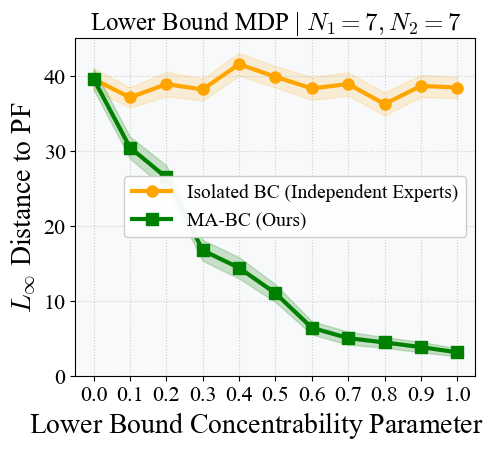

In [4]:

def plot_concentrability_sweep(s_div=20, s_shared=20, fixed_n_1=1, fixed_n_2=1, 
                               p_values=[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0], 
                               num_trials=30):
    print("="*65)
    print(f" CONCENTRABILITY P-SWEEP (Simulated Data Sharing Dropout) ")
    print("="*65 + "\n")
    
    iso_means, iso_stds, aug_means, aug_stds = [], [], [], []

    P_true, R_true = build_theoretical_mdp(s_div, s_shared, n_1=fixed_n_1, n_2=fixed_n_2, p=1.0, return_prob=0.5)
    solver = LowerBoundMDPSolver(P_true, R_true, s_div, n_1=fixed_n_1, n_2=fixed_n_2)
    
    pol_A_true = solver.solve_expert(0)
    pol_B_true = solver.solve_expert(1)
    
    pi_A_stochastic = np.eye(2)[pol_A_true]
    V_true_A = exact_theoretical_evaluation(pi_A_stochastic, solver)[:, 0]

    for p_val in p_values:
        iso_gaps, aug_gaps = [], []
        
        for trial in range(num_trials):
            data_A = collect_theoretical_trajectories(pol_A_true, fixed_n_1, solver, agent='A')
            data_B = collect_theoretical_trajectories(pol_B_true, fixed_n_2, solver, agent='B')
            
            pi_iso = build_theoretical_policy(data_A, solver.n_states)
            V_iso_A = exact_theoretical_evaluation(pi_iso, solver)[:, 0]
            iso_gaps.append(np.dot(solver.rho_A, V_true_A) - np.dot(solver.rho_A, V_iso_A))
            
            visited_A = dict(data_A)
            shared_from_B = []
            
            for s, a in data_B:
                if s not in visited_A or visited_A[s] == a:
                    if np.random.rand() <= p_val:  
                        shared_from_B.append((s, a))
            
            pi_aug = build_theoretical_policy(data_A + shared_from_B, solver.n_states)
            V_aug_A = exact_theoretical_evaluation(pi_aug, solver)[:, 0]
            aug_gaps.append(np.dot(solver.rho_A, V_true_A) - np.dot(solver.rho_A, V_aug_A))
            
        iso_means.append(np.mean(iso_gaps))
        iso_stds.append(np.std(iso_gaps))
        aug_means.append(np.mean(aug_gaps))
        aug_stds.append(np.std(aug_gaps))
        
        print(f"Sharing Fraction p = {p_val:.1f} | Iso Gap: {iso_means[-1]:.2f} | MA-BC Gap: {aug_means[-1]:.2f}")

    iso_means, iso_stds = np.array(iso_means), np.array(iso_stds)/np.sqrt(100)
    aug_means, aug_stds = np.array(aug_means), np.array(aug_stds)/np.sqrt(100)

    fig = plt.figure(figsize=(5, 5.2))
    ax = fig.gca()
    ax.set_facecolor('#f8f9fa')
    
    ax.plot(p_values, iso_means, 'o-', color='orange', linewidth=3, markersize=8, label='Isolated BC (Independent Experts)')
    ax.fill_between(p_values, np.maximum(0, iso_means - iso_stds), iso_means + iso_stds, color='orange', alpha=0.15)
    
    ax.plot(p_values, aug_means, 's-', color='green', linewidth=3, markersize=8, label='MA-BC (Ours)')
    ax.fill_between(p_values, np.maximum(0, aug_means - aug_stds), aug_means + aug_stds, color='green', alpha=0.2)

    ax.set_title(fr"Lower Bound MDP | $N_1={fixed_n_1}, N_2={fixed_n_2}$")
    
    ax.set_xlabel(r"Lower Bound Concentrability Parameter ($p$)")
    ax.set_ylabel(r"$L_\infty$ Distance to PF")
    ax.set_xticks(p_values)
    ax.grid(True, linestyle=":", alpha=0.6)
    
    ax.legend(loc="center right", framealpha=0.95)
    ax.set_ylim(bottom=0)
    
    fig.subplots_adjust(top=0.90, bottom=0.25, left=0.16, right=0.96)

    plt.savefig('concentrability_sweep.pdf', bbox_inches=None, dpi=300, transparent=True)
    plt.show()

plot_concentrability_sweep(
    s_div=100, s_shared=100,
    fixed_n_1=7,
    fixed_n_2=7,
    p_values=[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0], 
    num_trials=100
)

 CONCENTRABILITY C-SWEEP (Simulated Data Sharing Dropout) 

Sharing Fraction p = 0.0 | Iso Gap: 39.16 | MA-BC Gap: 39.16
Sharing Fraction p = 0.1 | Iso Gap: 37.55 | MA-BC Gap: 31.98
Sharing Fraction p = 0.2 | Iso Gap: 38.28 | MA-BC Gap: 23.90
Sharing Fraction p = 0.3 | Iso Gap: 40.84 | MA-BC Gap: 19.22
Sharing Fraction p = 0.4 | Iso Gap: 37.11 | MA-BC Gap: 13.37
Sharing Fraction p = 0.5 | Iso Gap: 39.07 | MA-BC Gap: 9.49
Sharing Fraction p = 0.6 | Iso Gap: 39.01 | MA-BC Gap: 7.79
Sharing Fraction p = 0.7 | Iso Gap: 39.18 | MA-BC Gap: 6.58
Sharing Fraction p = 0.8 | Iso Gap: 36.00 | MA-BC Gap: 3.78
Sharing Fraction p = 0.9 | Iso Gap: 37.59 | MA-BC Gap: 3.63


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


Sharing Fraction p = 1.0 | Iso Gap: 39.41 | MA-BC Gap: 2.87


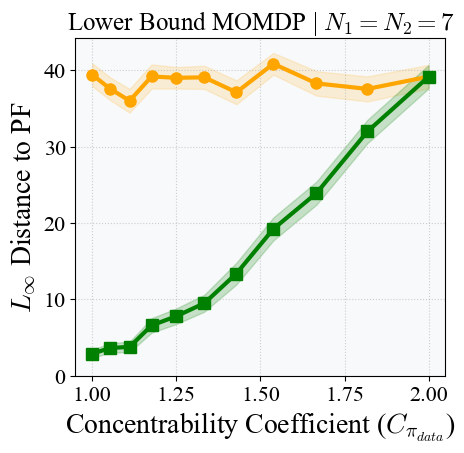

In [5]:
def plot_concentrability_sweep(s_div=20, s_shared=20, fixed_n_1=1, fixed_n_2=1, 
                               p_values=[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0], 
                               num_trials=30):
    print("="*65)
    print(f" CONCENTRABILITY C-SWEEP (Simulated Data Sharing Dropout) ")
    print("="*65 + "\n")
    
    iso_means, iso_stds, aug_means, aug_stds = [], [], [], []

    P_true, R_true = build_theoretical_mdp(s_div, s_shared, n_1=fixed_n_1, n_2=fixed_n_2, p=1.0, return_prob=0.5)
    solver = LowerBoundMDPSolver(P_true, R_true, s_div, n_1=fixed_n_1, n_2=fixed_n_2)
    
    pol_A_true = solver.solve_expert(0)
    pol_B_true = solver.solve_expert(1)
    
    pi_A_stochastic = np.eye(2)[pol_A_true]
    V_true_A = exact_theoretical_evaluation(pi_A_stochastic, solver)[:, 0]

    for p_val in p_values:
        iso_gaps, aug_gaps = [], []
        
        for trial in range(num_trials):
            data_A = collect_theoretical_trajectories(pol_A_true, fixed_n_1, solver, agent='A')
            data_B = collect_theoretical_trajectories(pol_B_true, fixed_n_2, solver, agent='B')
            
            pi_iso = build_theoretical_policy(data_A, solver.n_states)
            V_iso_A = exact_theoretical_evaluation(pi_iso, solver)[:, 0]
            iso_gaps.append(np.dot(solver.rho_A, V_true_A) - np.dot(solver.rho_A, V_iso_A))
            
            visited_A = dict(data_A)
            shared_from_B = []
            
            for s, a in data_B:
                if s not in visited_A or visited_A[s] == a:
                    if np.random.rand() <= p_val:  
                        shared_from_B.append((s, a))
            
            pi_aug = build_theoretical_policy(data_A + shared_from_B, solver.n_states)
            V_aug_A = exact_theoretical_evaluation(pi_aug, solver)[:, 0]
            aug_gaps.append(np.dot(solver.rho_A, V_true_A) - np.dot(solver.rho_A, V_aug_A))
            
        iso_means.append(np.mean(iso_gaps))
        iso_stds.append(np.std(iso_gaps))
        aug_means.append(np.mean(aug_gaps))
        aug_stds.append(np.std(aug_gaps))
        
        print(f"Sharing Fraction p = {p_val:.1f} | Iso Gap: {iso_means[-1]:.2f} | MA-BC Gap: {aug_means[-1]:.2f}")

    iso_means = np.array(iso_means)
    iso_sems = np.array(iso_stds) / np.sqrt(num_trials)
    aug_means = np.array(aug_means)
    aug_sems = np.array(aug_stds) / np.sqrt(num_trials)

    total_N = fixed_n_1 + fixed_n_2
    c_values = np.array([total_N / (fixed_n_1 + p * fixed_n_2) for p in p_values])
    
    sort_idx = np.argsort(c_values)
    c_values = c_values[sort_idx]
    iso_means = iso_means[sort_idx]
    iso_sems = iso_sems[sort_idx]
    aug_means = aug_means[sort_idx]
    aug_sems = aug_sems[sort_idx]

    fig = plt.figure(figsize=(5, 5.2))
    ax = fig.gca()
    ax.set_facecolor('#f8f9fa')
    
    ax.plot(c_values, iso_means, 'o-', color='orange', linewidth=3, markersize=8, label='Isolated BC (Independent Experts)')
    ax.fill_between(c_values, np.maximum(0, iso_means - iso_sems), iso_means + iso_sems, color='orange', alpha=0.15)
    
    ax.plot(c_values, aug_means, 's-', color='green', linewidth=3, markersize=8, label='MA-BC (Ours)')
    ax.fill_between(c_values, np.maximum(0, aug_means - aug_sems), aug_means + aug_sems, color='green', alpha=0.2)

    ax.set_title(fr"Lower Bound MOMDP | $N_1=N_2={fixed_n_2}$")
    
    ax.set_xlabel(r"Concentrability Coefficient ($C_{\pi_{data}}$)")
    ax.set_ylabel(r"$L_\infty$ Distance to PF")
    
    ax.grid(True, linestyle=":", alpha=0.6)
    
    ax.set_ylim(bottom=0)
    
    fig.subplots_adjust(top=0.90, bottom=0.25, left=0.24, right=0.98)

    plt.savefig('concentrability_sweep.pdf', bbox_inches=None, dpi=300, transparent=True)
    plt.show()

plot_concentrability_sweep(
    s_div=100, s_shared=100,
    fixed_n_1=7,
    fixed_n_2=7,
    p_values=[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0], 
    num_trials=100
)